In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import cv2
import keras
from numpy import random
import tensorflow as tf
import tensorflow_datasets as tfds
from matplotlib import pyplot as plt
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D
from keras.layers import MaxPooling2D, BatchNormalization
from keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
from keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import classification_report ,confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from keras.models import Model
from keras.layers import Input, Conv2D, BatchNormalization, Activation, Add, Flatten, Dense, GlobalAveragePooling2D, Reshape, Multiply
import seaborn as sns
import os

In [3]:
# Thư mục chứa dữ liệu
train_folder = "/content/drive/MyDrive/Colab Notebooks/Data/train"
valid_folder = "/content/drive/MyDrive/Colab Notebooks/Data/valid"
test_folder = "/content/drive/MyDrive/Colab Notebooks/Data/test"

In [4]:
input_shape = (224,224,3)
num_classes = 4

# Data generators
train_datagen = ImageDataGenerator(
    dtype='float32',
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    preprocessing_function=preprocess_input
)

val_datagen = ImageDataGenerator(
    dtype='float32',
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    dtype='float32',
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_folder,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical',
)

test_generator = test_datagen.flow_from_directory(
    test_folder,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False,
)

validation_generator = val_datagen.flow_from_directory(
    valid_folder,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical',
)

Found 613 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Found 72 images belonging to 4 classes.


In [5]:
# MobileNetV2 model
input_tensor = Input(shape=(224, 224, 3))
mobilenetv2 = MobileNetV2(include_top=False, weights='imagenet', input_tensor=input_tensor)

x = mobilenetv2.layers[-1].output
x = Conv2D(512, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=input_tensor, outputs=predictions)
model.summary()

<ipython-input-5-b4c77d446be7>:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenetv2 = MobileNetV2(include_top=False, weights='imagenet', input_tensor=input_tensor)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise_BN 

 Total params: 9,210,948 (35.14 MB)

 Trainable params: 9,175,812 (35.00 MB)

 Non-trainable params: 35,136 (137.25 KB)

In [6]:
# Compile model
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import os

# Xác định thư mục lưu trữ logs trên Google Colab
log_dir = "logs/fit"

# Khởi tạo TensorBoard callback
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Khởi tạo EarlyStopping callback
early_stopping_monitor = EarlyStopping(patience=40)

epochs = 100
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    verbose=1,
    callbacks=[tensorboard_callback, early_stopping_monitor],
    batch_size=64
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 186s 14s/step - accuracy: 0.3025 - loss: 1.3809 - val_accuracy: 0.3194 - val_loss: 1.4076
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4203 - loss: 1.3017 - val_accuracy: 0.3056 - val_loss: 1.4257
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5823 - loss: 1.2036 - val_accuracy: 0.3056 - val_loss: 1.3639
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6268 - loss: 1.0715 - val_accuracy: 0.3333 - val_loss: 1.3131
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6375 - loss: 0.9710 - val_accuracy: 0.3194 - val_loss: 1.3047
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6605 - loss: 0.8948 - val_accuracy: 0.3750 - val_loss: 1.2677
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6867 - loss: 0.8311 - val_accuracy: 0.3611 - val_loss: 1.2426
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7102 - loss: 0.7408 - val_accuracy: 0.3889 -

In [9]:
# Đánh giá mô hình
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_acc}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 50s 12s/step - accuracy: 0.8074 - loss: 0.6716
Test accuracy: 0.6793650984764099


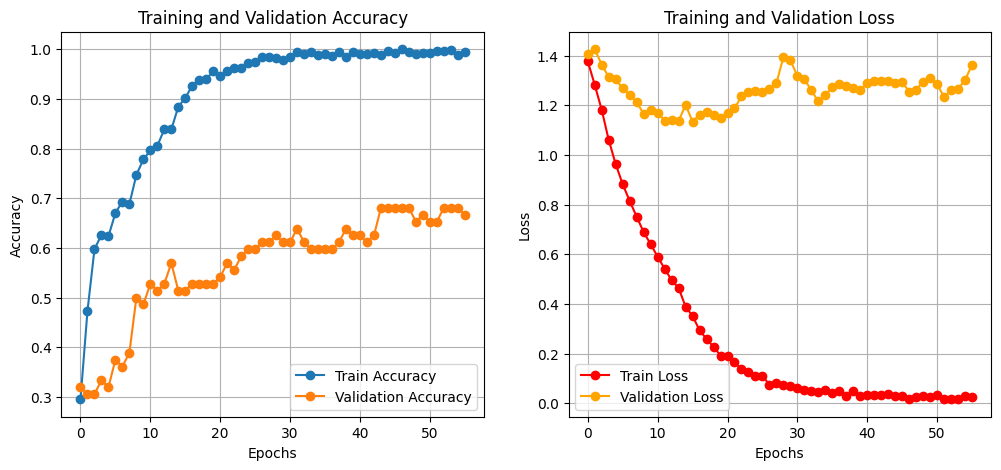

In [11]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))  # Số epoch đã huấn luyện

# Vẽ biểu đồ Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy", marker='o')
plt.plot(epochs_range, val_acc, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

# Vẽ biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss", marker='o', color='red')
plt.plot(epochs_range, val_loss, label="Validation Loss", marker='o', color='orange')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
# # Đánh giá chi tiết
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


              precision    recall  f1-score   support

           0       0.69      0.87      0.77       120
           1       0.48      0.98      0.65        51
           2       1.00      0.98      0.99        54
           3       1.00      0.08      0.14        90

    accuracy                           0.68       315
   macro avg       0.79      0.73      0.64       315
weighted avg       0.80      0.68      0.61       315



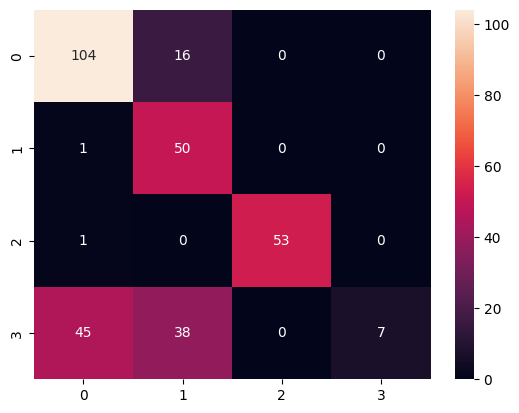

In [13]:
# # Báo cáo chính xác, độ nhạy, ma trận nhầm lẫn
print(classification_report(y_true, y_pred_classes))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 522ms/step
AUC for class 0: 0.8732
AUC for class 1: 0.9690
AUC for class 2: 0.9816
AUC for class 3: 0.8847
Macro AUC: 0.9271


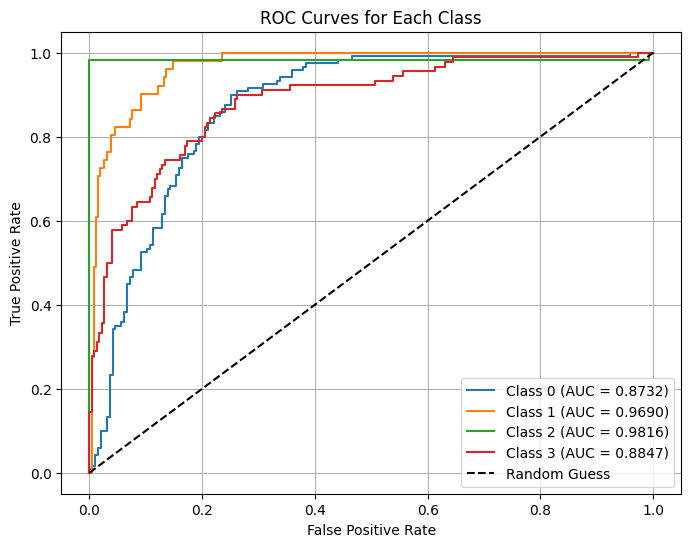

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

# Chuyển đổi y_true thành one-hot encoding (vì đây là multi-class)
y_true_one_hot = to_categorical(y_true, num_classes=4)

# Đảm bảo y_pred là xác suất dự đoán (từ model.predict)
y_pred_probs = model.predict(test_generator)

# Tính AUC cho từng lớp
auc_scores = roc_auc_score(y_true_one_hot, y_pred_probs, average=None)

# Hiển thị AUC từng lớp
for i, auc in enumerate(auc_scores):
    print(f"AUC for class {i}: {auc:.4f}")

# Tính AUC trung bình (macro)
auc_macro = roc_auc_score(y_true_one_hot, y_pred_probs, average="macro")
print(f"Macro AUC: {auc_macro:.4f}")

# Vẽ đường ROC cho từng class
plt.figure(figsize=(8, 6))
for i in range(4):  # 4 lớp
    fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc_scores[i]:.4f})')

# Vẽ đường chéo tham chiếu (random guess)
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

# Thiết lập đồ thị
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Each Class")
plt.legend()
plt.grid()
plt.show()

In [15]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize labels (chuyển thành dạng One-hot)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])

# Tính AUC macro và micro
auc_macro = roc_auc_score(y_true_bin, y_pred_probs, average='macro', multi_class='ovr')
auc_micro = roc_auc_score(y_true_bin, y_pred_probs, average='micro', multi_class='ovr')

print(f"Macro-AUC: {auc_macro:.4f}")
print(f"Micro-AUC: {auc_micro:.4f}")

Macro-AUC: 0.9271
Micro-AUC: 0.8698
